In [126]:
from dotenv import load_dotenv
import os

from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

API_KEY = os.getenv("GEMINI_API_KEY")

In [127]:
from pydantic import BaseModel, Field
from typing import Literal


class llm_schema(BaseModel):
    category: Literal["video", "image", "code", "audio"] = Field(...,
                                                                 description="Ushbu kategoriyalardan bittasini tanlab oling !")
    topic: str = Field(..., description="Ushbu malumot yuzasidan unga mos bitta mavzu tanlang !")


llm = ChatGoogleGenerativeAI(api_key=API_KEY, model="gemini-3-flash-preview")

In [128]:
from typing import TypedDict, List, Annotated
from operator import add


class graph_schema(TypedDict):
    user_input: str
    topic: str
    category: str
    video_prompts: Annotated[List[str], add]
    image_prompts: Annotated[List[str], add]
    code_prompts: Annotated[List[str], add]
    audio_prompts: Annotated[List[str], add]

In [129]:


def routing_graph(state: graph_schema):
    input = state["user_input"]
    llm_with_schema = llm.with_structured_output(llm_schema)
    result = llm_with_schema.invoke(input)
    return {"topic": result.topic, "category": result.category}


def get_category(state: graph_schema) -> Literal["video", "image", "code", "audio"]:
    return state["category"]


def generate_prompt_video(state: graph_schema):
    topic = state['topic']
    result = llm.invoke(f"Shu {topic} mavzudagi video uchun professional to'liq holda prompt yozib ber !").content
    return {"video_prompts": [result[0]['text']]}


def generate_prompt_image(state: graph_schema):
    topic = state['topic']
    result = llm.invoke(f"Shu {topic} mavzudagi rasim uchun professional to'liq holda prompt yozib !").content
    return {"image_prompts": [result[0]['text']]}


def generate_prompt_audio(state: graph_schema):
    topic = state['topic']
    result = llm.invoke(f"Shu {topic} mavzudagi audio uchun professional to'liq holda prompt yozib !").content
    return {"audio_prompts": [result[0]['text']]}


def generate_prompt_code(state: graph_schema):
    topic = state['topic']
    result = llm.invoke(
        f"Shu {topic} mavzudagi dasturlash kodlarini AIga yozdirishim uchun professional prompt tayorlab bering !").content
    return {"code_prompts": [result[0]['text']]}


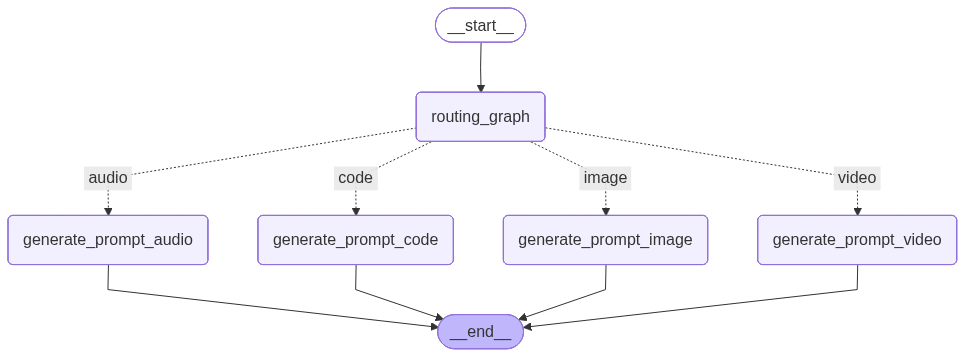

In [130]:
from langgraph.graph import START, StateGraph, END

graph = StateGraph(graph_schema)

graph.add_node("routing_graph", routing_graph)
# graph.add_node("get_category", get_category)
graph.add_node("generate_prompt_video", generate_prompt_video)
graph.add_node("generate_prompt_image", generate_prompt_image)
graph.add_node("generate_prompt_audio", generate_prompt_audio)
graph.add_node("generate_prompt_code", generate_prompt_code)

graph.add_edge(START, "routing_graph")
graph.add_conditional_edges("routing_graph", get_category, {
    "image": "generate_prompt_image",
    "audio": "generate_prompt_audio",
    "code": "generate_prompt_code",
    "video": "generate_prompt_video"
})
graph.add_edge("generate_prompt_image", END)
graph.add_edge("generate_prompt_video", END)
graph.add_edge("generate_prompt_audio", END)
graph.add_edge("generate_prompt_code", END)

router_graph = graph.compile()

from IPython.display import display, Image

Image(router_graph.get_graph().draw_mermaid_png())

In [131]:
yakuniy_natija = router_graph.invoke({
    "user_input": "Men dasturlashni video korib o'rgana olmayapman. Shunga ai ga dasturlash haqida html roadmap tuzdirmoqchiman shunga prompt yozib ber",
    "topic": '',
    "category": '',
    "video_prompts": [],
    "image_prompts": [],
    "code_prompts": [],
    "audio_prompts": [],
})
yakuniy_natija

{'user_input': "Men dasturlashni video korib o'rgana olmayapman. Shunga ai ga dasturlash haqida html roadmap tuzdirmoqchiman shunga prompt yozib ber",
 'topic': "Dasturlashni o'rganish uchun HTML yo'l xaritasi (roadmap) yaratish uchun prompt",
 'category': 'code',
 'video_prompts': [],
 'image_prompts': [],
 'code_prompts': ['Sizga AI (masalan, ChatGPT, Claude yoki Gemini) dan eng yuqori sifatli javobni olish uchun maxsus ishlab chiqilgan bir necha xil professional promptlarni taqdim etaman.\n\nEhtiyojingizga qarab quyidagilardan birini tanlashingiz mumkin:\n\n### 1-Variant: Mukammal "Zero to Hero" Yo\'l xaritasi (Eng yaxshi tanlov)\nBu prompt AIdan nafaqat nazariya, balki har bir bosqich uchun kod namunalari va topshiriqlarni ham so\'raydi.\n\n> **Prompt:**\n> "Sen tajribali Senior Web Developer va professional ustozsan. Menga HTML-ni mutlaqo noldan professional darajagacha o\'rganish uchun mukammal va tizimli yo\'l xaritasi (Roadmap) tayyorlab ber.\n> \n> Yo\'l xaritasi quyidagi bo\'